# Model training controls

In [46]:
import joblib
import optuna
from pathlib import Path
import acm.observables.bgs as project

import matplotlib.pyplot as plt
%matplotlib inline

In [58]:
study_dir = Path('/pscratch/sd/s/sbouchar/acm/bgs/trained_models/study/')
stat_name = 'ds_xiqg'

## Stydy visualizations

### 1- TPCF

In [59]:
study = joblib.load(study_dir / f'{stat_name}.pkl')
print(f'Best trial for {stat_name}: {study.best_trial.number}')
trial = study.best_trial
print(f'  Value: {trial.value}')
print('  Params: ')
for key, value in trial.params.items():
    print(f'    {key}: {value}')

Best trial for ds_xiqg: 81
  Value: 0.0005202646716497838
  Params: 
    learning_rate: 0.00550592520674234
    weight_decay: 7.357030408928419e-05
    n_layers: 4
    n_hidden: 577
    dropout_rate: 6.61361305774052e-05


In [49]:
optuna.visualization.plot_optimization_history(study)

In [50]:
optuna.visualization.plot_slice(study)

In [51]:
optuna.visualization.plot_param_importances(study)

In [52]:
optuna.visualization.plot_parallel_coordinate(study)

## Model errors

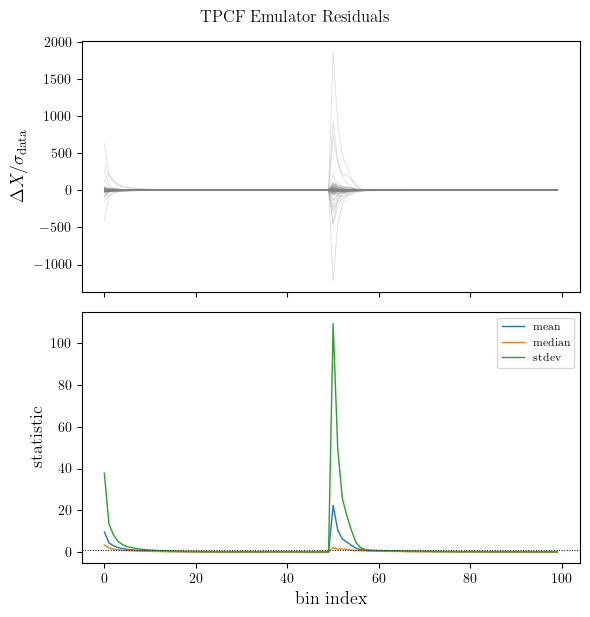

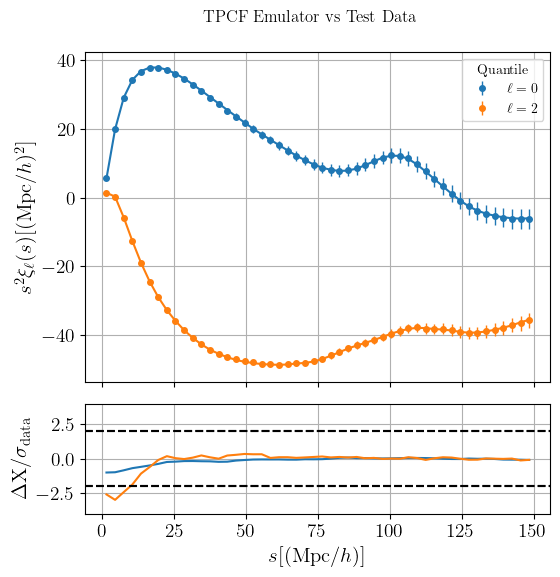

In [ ]:
obs = getattr(project, stat_name)()
fig, ax = obs.plot_emulator_residuals(figsize=(6,6))
fig.suptitle(f'{stat_name.upper()} Emulator Residuals', y=1.02);

obs.select_filters = dict(cosmo_idx=0, hod_idx=0, ells=0)
fig, ax = obs.plot_observable(model_params=obs.x)
ax[0].legend(title='Quantile')
fig.suptitle(f'{stat_name.upper()} Emulator vs Test Data', y=0.95);